# RELDEC Baselines Only (Flooding, Random, Round Robin)

This notebook evaluates baseline schedulers only, over fixed SNR points:

- flooding
- random sequential
- round_robin

SNR sweep: 2.0, 2.5, 3.0, 3.25, 3.5 dB

The simulation is incremental and resumable:

- Results are accumulated in a JSON state file on disk.
- Re-running the simulation cell adds more frames to existing totals.
- BER/FER estimates improve as more frames are added.

In [13]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

from reldec_core import (
    ReldecDecoderSuite,
    bpsk_awgn_llr,
    get_code_preset,
    load_parity_check_from_sparse_csv,
    nominal_code_rate,
)

In [30]:
ROOT = Path.cwd()
if not (ROOT / "RELDEC").exists():
    ROOT = Path("/root/Research/RithvikDecoder/Decoder")

RELDEC_DIR = ROOT / "RELDEC"
RUNS_DIR = RELDEC_DIR / "notebook_runs" / "baseline_accumulator"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

CODE = "wran"  # "ab" or "wran"
METHODS = ["flooding", "random", "round_robin"]
SNR_DB = [3.0]

# Re-run the simulation cell to add more frames to existing totals.
ADDITIONAL_FRAMES_PER_POINT = 5000
SAVE_EVERY_FRAMES = 25
BASE_SEED = 20260324
RANDOM_CODEWORDS = False

state_tag = "_".join(str(x).replace(".", "p") for x in SNR_DB)
STATE_FILE = RUNS_DIR / f"baselines_{CODE}_{state_tag}.json"

preset = get_code_preset(CODE)
h = load_parity_check_from_sparse_csv(preset.matrix_csv)
suite = ReldecDecoderSuite(h)

I_MAX = int(preset.inference_i_max)
CODE_RATE = float(nominal_code_rate(h))

print(f"ROOT:       {ROOT}")
print(f"RUNS_DIR:   {RUNS_DIR}")
print(f"STATE_FILE: {STATE_FILE}")
print(f"CODE:       {CODE}")
print(f"H shape:    {h.shape}, nnz={h.nnz}, rate={CODE_RATE:.6f}, i_max={I_MAX}")
print(f"METHODS:    {METHODS}")
print(f"SNR(dB):    {SNR_DB}")
print(f"ADD_FRAMES_PER_POINT: {ADDITIONAL_FRAMES_PER_POINT}")

ROOT:       /root/Research/RithvikDecoder/Decoder
RUNS_DIR:   /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/baseline_accumulator
STATE_FILE: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/baseline_accumulator/baselines_wran_3p0.json
CODE:       wran
H shape:    (128, 384), nnz=1296, rate=0.666667, i_max=5
METHODS:    ['flooding', 'random', 'round_robin']
SNR(dB):    [3.0]
ADD_FRAMES_PER_POINT: 5000


In [15]:
def _now() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")


def _key(method: str, snr_db: float) -> str:
    return f"{method}|{snr_db:.2f}"


def _new_record() -> dict:
    return {
        "frames": 0,
        "bit_errors": 0,
        "frame_errors": 0,
        "messages": 0,
        "iterations": 0,
        "converged_frames": 0,
    }


def _initialize_state() -> dict:
    records = {}
    for method in METHODS:
        for snr_db in SNR_DB:
            records[_key(method, float(snr_db))] = _new_record()

    return {
        "config": {
            "code": CODE,
            "methods": METHODS,
            "snr_db": SNR_DB,
            "i_max": I_MAX,
            "code_rate": CODE_RATE,
            "random_codewords": bool(RANDOM_CODEWORDS),
            "matrix_csv": str(preset.matrix_csv),
        },
        "records": records,
        "run_history": [],
        "created_at": _now(),
        "updated_at": _now(),
    }


def _save_state(state: dict) -> None:
    state["updated_at"] = _now()
    STATE_FILE.parent.mkdir(parents=True, exist_ok=True)
    STATE_FILE.write_text(json.dumps(state, indent=2), encoding="utf-8")


def _load_state() -> dict:
    if not STATE_FILE.exists():
        state = _initialize_state()
        _save_state(state)
        return state

    state = json.loads(STATE_FILE.read_text(encoding="utf-8"))

    # Back-fill missing keys for forward compatibility.
    for method in METHODS:
        for snr_db in SNR_DB:
            k = _key(method, float(snr_db))
            if k not in state.get("records", {}):
                state.setdefault("records", {})[k] = _new_record()

    cfg = state.get("config", {})
    expected_methods = list(METHODS)
    expected_snr = [float(x) for x in SNR_DB]
    if cfg.get("code") != CODE or cfg.get("methods") != expected_methods or [float(x) for x in cfg.get("snr_db", [])] != expected_snr:
        raise ValueError(
            "State file config mismatch. Update CODE/SNR_DB/METHODS to match existing file, or delete STATE_FILE to start fresh."
        )

    return state


def _record_to_row(method: str, snr_db: float, rec: dict) -> dict:
    frames = int(rec["frames"])
    n = suite.n
    ber = (float(rec["bit_errors"]) / (frames * n)) if frames else float("nan")
    fer = (float(rec["frame_errors"]) / frames) if frames else float("nan")
    avg_messages = (float(rec["messages"]) / frames) if frames else float("nan")
    avg_iterations = (float(rec["iterations"]) / frames) if frames else float("nan")
    conv_rate = (float(rec["converged_frames"]) / frames) if frames else float("nan")

    return {
        "code": CODE,
        "method": method,
        "snr_db": float(snr_db),
        "frames": frames,
        "frame_errors": int(rec["frame_errors"]),
        "bit_errors": int(rec["bit_errors"]),
        "ber": ber,
        "fer": fer,
        "avg_messages": avg_messages,
        "avg_iterations": avg_iterations,
        "convergence_rate": conv_rate,
    }

In [11]:
state = _load_state()

existing_rows = []
for method in METHODS:
    for snr_db in SNR_DB:
        rec = state["records"][_key(method, float(snr_db))]
        existing_rows.append(_record_to_row(method, float(snr_db), rec))

if pd is not None:
    preview_df = pd.DataFrame(existing_rows).sort_values(["method", "snr_db"])
    display(preview_df[["method", "snr_db", "frames", "frame_errors", "ber", "fer", "avg_messages"]])
else:
    for row in sorted(existing_rows, key=lambda r: (r["method"], r["snr_db"])):
        print(row)

print(f"Loaded accumulator state: {STATE_FILE}")

,method,snr_db,frames,frame_errors,ber,fer,avg_messages
0,flooding,2.00,200,10,0.00478,0.050,17062.5
1,flooding,2.50,200,1,0.00040,0.005,10687.5
2,flooding,3.00,200,0,0.00000,0.000,7837.5
3,flooding,3.25,200,0,0.00000,0.000,6900.0
4,flooding,3.50,200,0,0.00000,0.000,6210.0
5,random,2.00,200,6,0.00289,0.030,10222.5
6,random,2.50,200,1,0.00052,0.005,6915.0
7,random,3.00,200,0,0.00000,0.000,4957.5
8,random,3.25,200,0,0.00000,0.000,4305.0
9,random,3.50,200,0,0.00000,0.000,3967.5


Loaded accumulator state: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/baseline_accumulator/baselines_ab_2p0_2p5_3p0_3p25_3p5.json


In [32]:
# Re-run this cell any time to add more frames to existing results.
if ADDITIONAL_FRAMES_PER_POINT <= 0:
    raise ValueError("ADDITIONAL_FRAMES_PER_POINT must be > 0")

state = _load_state()

seed_offset = int(sum(int(r["frames"]) for r in state["records"].values()))
rng = np.random.default_rng(BASE_SEED + seed_offset)

added_total = 0
start_t = time.time()

for snr_db in SNR_DB:
    snr_db = float(snr_db)
    print(f"[simulate] snr={snr_db:.2f} dB")

    for method in METHODS:
        rec = state["records"][_key(method, snr_db)]

        for i in range(ADDITIONAL_FRAMES_PER_POINT):
            if RANDOM_CODEWORDS:
                tx_bits = rng.integers(0, 2, size=suite.n, dtype=np.uint8)
            else:
                tx_bits = np.zeros(suite.n, dtype=np.uint8)

            llr = bpsk_awgn_llr(tx_bits, ebn0_db=snr_db, code_rate=CODE_RATE, rng=rng)

            if method == "flooding":
                decoded = suite.decode_flooding(llr, i_max=I_MAX)
            elif method == "random":
                decoded = suite.decode_random_sequential(llr, i_max=I_MAX, rng=rng)
            elif method == "round_robin":
                decoded = suite.decode_round_robin(llr, i_max=I_MAX)
            else:
                raise ValueError(f"Unsupported method in baseline notebook: {method}")

            bit_errors = int(np.count_nonzero(decoded.bits != tx_bits))
            rec["frames"] += 1
            rec["bit_errors"] += bit_errors
            rec["frame_errors"] += int(bit_errors > 0)
            rec["messages"] += int(decoded.messages)
            rec["iterations"] += int(decoded.iterations)
            rec["converged_frames"] += int(decoded.converged)

            added_total += 1
            if (i + 1) % SAVE_EVERY_FRAMES == 0:
                _save_state(state)

        row = _record_to_row(method, snr_db, rec)
        print(
            f"  - {method:11s} frames={row['frames']:7d} "
            f"FER={row['fer']:.6e} BER={row['ber']:.6e} avg_msgs={row['avg_messages']:.2f}"
        )

state.setdefault("run_history", []).append(
    {
        "timestamp": _now(),
        "added_frames_per_point": int(ADDITIONAL_FRAMES_PER_POINT),
        "total_new_frames": int(added_total),
        "random_codewords": bool(RANDOM_CODEWORDS),
    }
)
_save_state(state)

elapsed = time.time() - start_t
print(f"[done] Added {added_total} frames across all SNR/method combinations in {elapsed:.1f}s")
print(f"[done] State saved to: {STATE_FILE}")

[simulate] snr=3.00 dB
  - flooding    frames=  16500 FER=2.576970e-01 BER=4.013100e-03 avg_msgs=5196.41
  - random      frames=  16500 FER=8.333333e-02 BER=2.331439e-03 avg_msgs=3743.32
  - round_robin frames=  16500 FER=6.418182e-02 BER=1.907670e-03 avg_msgs=3567.06
[done] Added 15000 frames across all SNR/method combinations in 106.6s
[done] State saved to: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/baseline_accumulator/baselines_wran_3p0.json


In [33]:
state = _load_state()

rows = []
for method in METHODS:
    for snr_db in SNR_DB:
        rec = state["records"][_key(method, float(snr_db))]
        rows.append(_record_to_row(method, float(snr_db), rec))

rows = sorted(rows, key=lambda r: (r["method"], r["snr_db"]))

print("Final accumulated results")
print("=" * 90)

if pd is not None:
    df = pd.DataFrame(rows)
    cols = [
        "code",
        "method",
        "snr_db",
        "frames",
        "frame_errors",
        "ber",
        "fer",
        "avg_messages",
        "avg_iterations",
        "convergence_rate",
    ]
    display(df[cols])

    summary = (
        df.groupby("method", as_index=False)
        .agg(
            total_frames=("frames", "sum"),
            total_frame_errors=("frame_errors", "sum"),
            mean_ber=("ber", "mean"),
            mean_fer=("fer", "mean"),
            mean_avg_messages=("avg_messages", "mean"),
        )
        .sort_values("mean_fer")
    )
    print("Method summary (mean over requested SNR points)")
    display(summary)
else:
    for row in rows:
        print(row)

Final accumulated results


,code,method,snr_db,frames,frame_errors,ber,fer,avg_messages,avg_iterations,convergence_rate
0,wran,flooding,3.0,16500,4252,0.004013,0.257697,5196.410182,4.009576,0.742303
1,wran,random,3.0,16500,1375,0.002331,0.083333,3743.319273,2.888364,0.916727
2,wran,round_robin,3.0,16500,1059,0.001908,0.064182,3567.063273,2.752364,0.935879


Method summary (mean over requested SNR points)


,method,total_frames,total_frame_errors,mean_ber,mean_fer,mean_avg_messages
2,round_robin,16500,1059,0.001908,0.064182,3567.063273
1,random,16500,1375,0.002331,0.083333,3743.319273
0,flooding,16500,4252,0.004013,0.257697,5196.410182


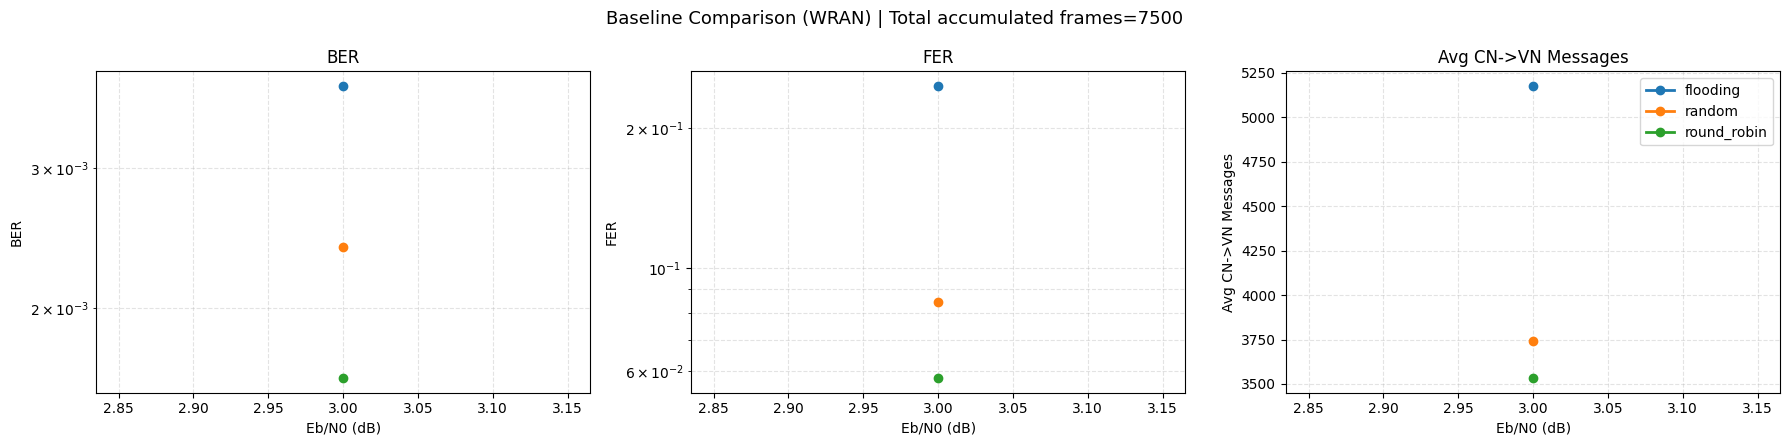

In [26]:
state = _load_state()
rows = []
for method in METHODS:
    for snr_db in SNR_DB:
        rec = state["records"][_key(method, float(snr_db))]
        rows.append(_record_to_row(method, float(snr_db), rec))

metric_specs = [
    ("ber", "BER", True),
    ("fer", "FER", True),
    ("avg_messages", "Avg CN->VN Messages", False),
]

fig, axes = plt.subplots(1, len(metric_specs), figsize=(18, 4.5))

for ax, (metric_key, metric_title, logy) in zip(axes, metric_specs):
    for method in METHODS:
        method_rows = [r for r in rows if r["method"] == method]
        method_rows = sorted(method_rows, key=lambda r: float(r["snr_db"]))
        x = [float(r["snr_db"]) for r in method_rows]
        y_raw = [float(r[metric_key]) for r in method_rows]
        y = [max(v, 1e-12) if logy else v for v in y_raw]

        if logy:
            ax.semilogy(x, y, marker="o", linewidth=2.0, label=method)
        else:
            ax.plot(x, y, marker="o", linewidth=2.0, label=method)

    ax.set_title(metric_title)
    ax.set_xlabel("Eb/N0 (dB)")
    ax.set_ylabel(metric_title)
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

axes[-1].legend(loc="best")

total_frames = int(sum(r["frames"] for r in rows))
fig.suptitle(f"Baseline Comparison ({CODE.upper()}) | Total accumulated frames={total_frames}", fontsize=13)
fig.tight_layout()
plt.show()

## How To Add More Frames Later

1. Set `ADDITIONAL_FRAMES_PER_POINT` to the extra amount you want.
2. Re-run the simulation cell.
3. Re-run the table and plot cells.

Your previous totals are preserved in `STATE_FILE`, so each run only appends new evidence and improves BER/FER confidence.